In [ ]:
# ## Imports

import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import (
    classification_report, roc_auc_score,
    recall_score, precision_score, accuracy_score,
)

MODEL_BASE_PATH  = Path("../baseline_models_2_2_2/cardio_xgb_baseline_model.pkl")
MODEL_REFINED_PATH  = Path("../refined_models")

OUTPUT_DIR = Path("../../outputs/models")


In [34]:
# ## 1 · Load Test Sets & Models

test_df    = pd.read_csv("../../data/test_train_val_sets/cardio_baseline_test.csv")
test_fe_df = pd.read_csv("../../data/test_train_val_sets/cardio_fe_test.csv")


X_test = test_df.drop(columns=["cardio", "stratify"])
y_test = test_df["cardio"]
X_test_fe = test_fe_df.drop(columns=["cardio"])
y_test_fe = test_fe_df["cardio"]

female_mask = test_df["gender"].values == 0
male_mask   = test_df["gender"].values == 1

def load(path):
    with open(path, "rb") as f:
        return pickle.load(f)

models = {
    "Baseline":    (load(MODEL_BASE_PATH), X_test),
    "Tuned":       (load(MODEL_REFINED_PATH/ "cardio_xgb_tuned.pkl"),           X_test),
    "Monotone":    (load(MODEL_REFINED_PATH/ "cardio_xgb_monotone.pkl"),        X_test),   # uses clipped X_test
    "Weighted":    (load(MODEL_REFINED_PATH/ "cardio_xgb_weighted.pkl"),        X_test),
    "Constrained": (load(MODEL_REFINED_PATH/ "cardio_xgb_constrained.pkl"),     X_test),
    "FE":          (load(MODEL_REFINED_PATH/ "cardio_xgb_fe.pkl"),              X_test_fe),
}

In [3]:
# X_test and y_test are the held‑out test set
assert len(X_test) == len(y_test)

import json

with open("../../config/dataset_split_sizes.json", "r") as f:
    expected = json.load(f)

assert len(test_df)  == expected["test"],  "Test size mismatch"
assert len(test_fe_df)  == expected["test"],  "Test size mismatch"

print("Dataset sizes validated.")


Dataset sizes validated.


In [4]:
# ## 2 · Bootstrap CI Helper

def bootstrap_ci(y_true, y_pred, y_prob, metric_fn, n_bootstraps=1000, ci=0.95):
    scores, rng = [], np.random.RandomState(42)
    for _ in range(n_bootstraps):
        idx = rng.randint(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(metric_fn(y_true[idx], y_pred[idx], y_prob[idx]))
    scores = np.sort(scores)
    lo = scores[int((1 - ci) / 2 * len(scores))]
    hi = scores[int((1 + ci) / 2 * len(scores))]
    return np.mean(scores), lo, hi

def auroc(yt, yp, ypr):     return roc_auc_score(yt, ypr)
def accuracy(yt, yp, ypr):  return accuracy_score(yt, yp)
def recall(yt, yp, ypr):    return recall_score(yt, yp)
def precision(yt, yp, ypr): return precision_score(yt, yp)

In [5]:
# ## 3 · Evaluate All Models

for model_name, (model, X) in models.items():
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    # choose correct y_test depending on model
    if model_name == "FE":
        y_true = y_test_fe
    else:
        y_true = y_test

    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    # validation checks
    assert len(y_pred) == len(y_true)
    assert len(y_prob) == len(y_true)
    
    # Gender masks applied to the correct X
    is_fe       = model_name == "FE"
    feat_mask   = female_mask  # same index, gender col not in FE features
    
    y_pred_f = model.predict(X[female_mask])
    y_prob_f = model.predict_proba(X[female_mask])[:, 1]
    y_pred_m = model.predict(X[male_mask])
    y_prob_m = model.predict_proba(X[male_mask])[:, 1]

    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")

    for label, yt, yp, ypr in [
        ("Overall", y_test.values,        y_pred,   y_prob),
        ("Female",  y_test[female_mask].values, y_pred_f, y_prob_f),
        ("Male",    y_test[male_mask].values,   y_pred_m, y_prob_m),
    ]:
        print(f"\n── {label} ──────────────────────────────")
        print(classification_report(yt, yp))
        for name, fn in [("AUROC", auroc), ("Accuracy", accuracy),
                         ("Recall", recall), ("Precision", precision)]:
            m, lo, hi = bootstrap_ci(yt, yp, ypr, fn)
            print(f"  {name:<12}: {m:.3f}  ({lo:.3f} – {hi:.3f})")


  Baseline

── Overall ──────────────────────────────
              precision    recall  f1-score   support

           0       0.72      0.78      0.74      5160
           1       0.75      0.69      0.72      5067

    accuracy                           0.73     10227
   macro avg       0.73      0.73      0.73     10227
weighted avg       0.73      0.73      0.73     10227

  AUROC       : 0.796  (0.787 – 0.805)
  Accuracy    : 0.731  (0.723 – 0.740)
  Recall      : 0.685  (0.674 – 0.697)
  Precision   : 0.750  (0.738 – 0.763)

── Female ──────────────────────────────
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      3369
           1       0.75      0.69      0.72      3280

    accuracy                           0.74      6649
   macro avg       0.74      0.73      0.73      6649
weighted avg       0.74      0.74      0.73      6649

  AUROC       : 0.803  (0.792 – 0.813)
  Accuracy    : 0.735  (0.724 – 0.746)
  Recall      :

In [46]:
import pandas as pd
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

def collect_results(label, yt, yp, ypr):
    row = {}
    for name, fn in [("AUROC", auroc), ("Accuracy", accuracy), ("Precision", precision)]:
        m, lo, hi = bootstrap_ci(yt, yp, ypr, fn)
        row[name] = f"{m:.3f} ({lo:.3f}–{hi:.3f})"
    report = classification_report(yt, yp, output_dict=True)
    row["Sensitivity"] = f"{report['1']['recall']:.3f}"

    row["F1"] = f"0: {report['0']['f1-score']:.3f} | 1: {report['1']['f1-score']:.3f}"
    return row
# ── collect all results ───────────────────────────────────────────────
overall_rows, female_rows, male_rows = [], [], []

for model_name, (model, X) in models.items():
    y_true = y_test_fe if model_name == "FE" else y_test

    y_pred   = model.predict(X)
    y_prob   = model.predict_proba(X)[:, 1]
    y_pred_f = model.predict(X[female_mask])
    y_prob_f = model.predict_proba(X[female_mask])[:, 1]
    y_pred_m = model.predict(X[male_mask])
    y_prob_m = model.predict_proba(X[male_mask])[:, 1]

    y_true_f = y_true[female_mask].values
    y_true_m = y_true[male_mask].values

    overall_rows.append({"Model": model_name, **collect_results("Overall", y_true.values, y_pred, y_prob)})
    female_rows.append( {"Model": model_name, **collect_results("Female",  y_true_f, y_pred_f, y_prob_f)})
    male_rows.append(   {"Model": model_name, **collect_results("Male",    y_true_m, y_pred_m, y_prob_m)})

df_overall = pd.DataFrame(overall_rows)
df_female  = pd.DataFrame(female_rows)
df_male    = pd.DataFrame(male_rows)

# ── styling helpers ───────────────────────────────────────────────────
HEADER_FILL   = PatternFill("solid", start_color="1F4E79")   # dark blue
ALT_FILL      = PatternFill("solid", start_color="D6E4F0")   # light blue
WHITE_FILL    = PatternFill("solid", start_color="FFFFFF")
HEADER_FONT   = Font(name="Arial", bold=True, color="FFFFFF", size=10)
BODY_FONT     = Font(name="Arial", size=10)
CENTER        = Alignment(horizontal="center", vertical="center")
LEFT          = Alignment(horizontal="left",   vertical="center")
THIN          = Side(style="thin", color="B0C4DE")
BORDER        = Border(left=THIN, right=THIN, top=THIN, bottom=THIN)

def write_sheet(ws, df, title):
    # title row
    ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=len(df.columns))
    title_cell = ws.cell(row=1, column=1, value=title)
    title_cell.font      = Font(name="Arial", bold=True, size=12, color="FFFFFF")
    title_cell.fill      = PatternFill("solid", start_color="0D2D4E")
    title_cell.alignment = CENTER

    # header row
    for col_idx, col_name in enumerate(df.columns, start=1):
        cell = ws.cell(row=2, column=col_idx, value=col_name)
        cell.font      = HEADER_FONT
        cell.fill      = HEADER_FILL
        cell.alignment = CENTER
        cell.border    = BORDER

    # data rows
    for row_idx, row in enumerate(df.itertuples(index=False), start=3):
        fill = ALT_FILL if (row_idx % 2 == 0) else WHITE_FILL
        for col_idx, value in enumerate(row, start=1):
            cell = ws.cell(row=row_idx, column=col_idx, value=value)
            cell.font      = BODY_FONT
            cell.fill      = fill
            cell.alignment = CENTER if col_idx > 1 else LEFT
            cell.border    = BORDER

    # column widths
    ws.column_dimensions["A"].width = 14          # Model column
    for col_idx in range(2, len(df.columns) + 1):
        ws.column_dimensions[get_column_letter(col_idx)].width = 16
    ws.row_dimensions[1].height = 22
    ws.row_dimensions[2].height = 18

# ── build workbook ────────────────────────────────────────────────────
wb = Workbook()
for sheet_name, df, title in [
    ("Overall", df_overall, "Model Evaluation — Overall"),
    ("Female",  df_female,  "Model Evaluation — Female"),
    ("Male",    df_male,    "Model Evaluation — Male"),
]:
    ws = wb.create_sheet(sheet_name)
    write_sheet(ws, df, title)

wb.remove(wb["Sheet"])   # remove default blank sheet
wb.save(OUTPUT_DIR/"model_evaluation_results.xlsx")
print("Saved - model_evaluation_results.xlsx")

Saved - model_evaluation_results.xlsx


In [23]:
# ## 4 · Side-by-Side Summary Table

rows = []
for model_name, (model, X) in models.items():
    for label, mask in [("Overall", slice(None)), ("Female", female_mask), ("Male", male_mask)]:
        yt  = y_test.values[mask]
        yp  = model.predict(X[mask])
        ypr = model.predict_proba(X[mask])[:, 1]
        rows.append({
            "Model":     model_name,
            "Subset":    label,
            "AUROC":     round(roc_auc_score(yt, ypr), 3),
            "Recall":    round(recall_score(yt, yp), 3),
            "Precision": round(precision_score(yt, yp), 3),
            "Accuracy":  round(accuracy_score(yt, yp), 3),
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

      Model  Subset  AUROC  Recall  Precision  Accuracy
   Baseline Overall  0.796   0.685      0.751     0.731
   Baseline  Female  0.803   0.693      0.751     0.735
   Baseline    Male  0.783   0.670      0.749     0.723
      Tuned Overall  0.797   0.690      0.748     0.732
      Tuned  Female  0.804   0.698      0.748     0.735
      Tuned    Male  0.783   0.677      0.749     0.725
   Monotone Overall  0.795   0.687      0.746     0.729
   Monotone  Female  0.803   0.697      0.748     0.735
   Monotone    Male  0.781   0.667      0.744     0.719
   Weighted Overall  0.783   0.713      0.728     0.726
   Weighted  Female  0.792   0.713      0.738     0.733
   Weighted    Male  0.767   0.713      0.712     0.713
Constrained Overall  0.792   0.655      0.759     0.726
Constrained  Female  0.800   0.664      0.762     0.732
Constrained    Male  0.776   0.637      0.753     0.715
         FE Overall  0.796   0.778      0.691     0.718
         FE  Female  0.803   0.783      0.694   

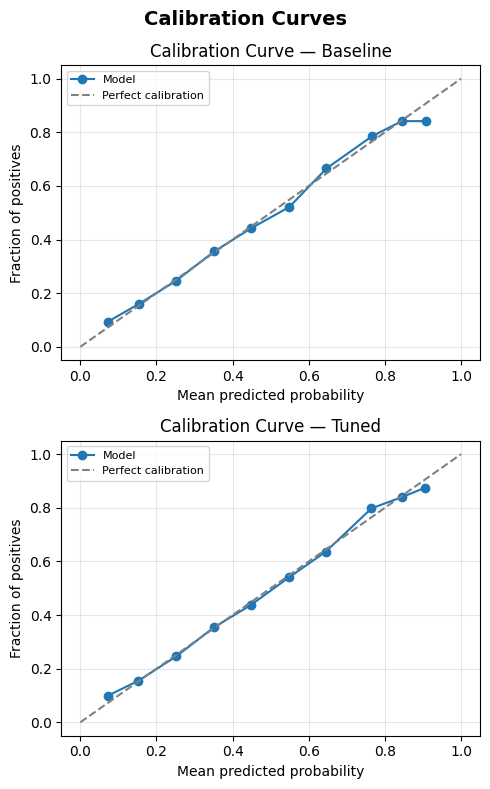

In [43]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(5, 8))
fig.suptitle("Calibration Curves", fontsize=14, fontweight="bold")

for ax, model_name in zip(axes, ["Baseline", "Tuned"]):
    model, X = models[model_name]
    y_prob = model.predict_proba(X)[:, 1]
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

    ax.plot(prob_pred, prob_true, marker="o", label="Model")
    ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfect calibration")
    ax.set_title(f"Calibration Curve — {model_name}")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "calibration_baseline_tuned.png", dpi=150, bbox_inches="tight", facecolor="#0d0d1b")
plt.show()

In [36]:
models_2 = {
    "Monotone":    (load(MODEL_REFINED_PATH/ "cardio_xgb_monotone.pkl"),        X_test),   # uses clipped X_test
    "Weighted":    (load(MODEL_REFINED_PATH/ "cardio_xgb_weighted.pkl"),        X_test),
    "Constrained": (load(MODEL_REFINED_PATH/ "cardio_xgb_constrained.pkl"),     X_test),
    "FE":          (load(MODEL_REFINED_PATH/ "cardio_xgb_fe.pkl"),              X_test_fe),
}

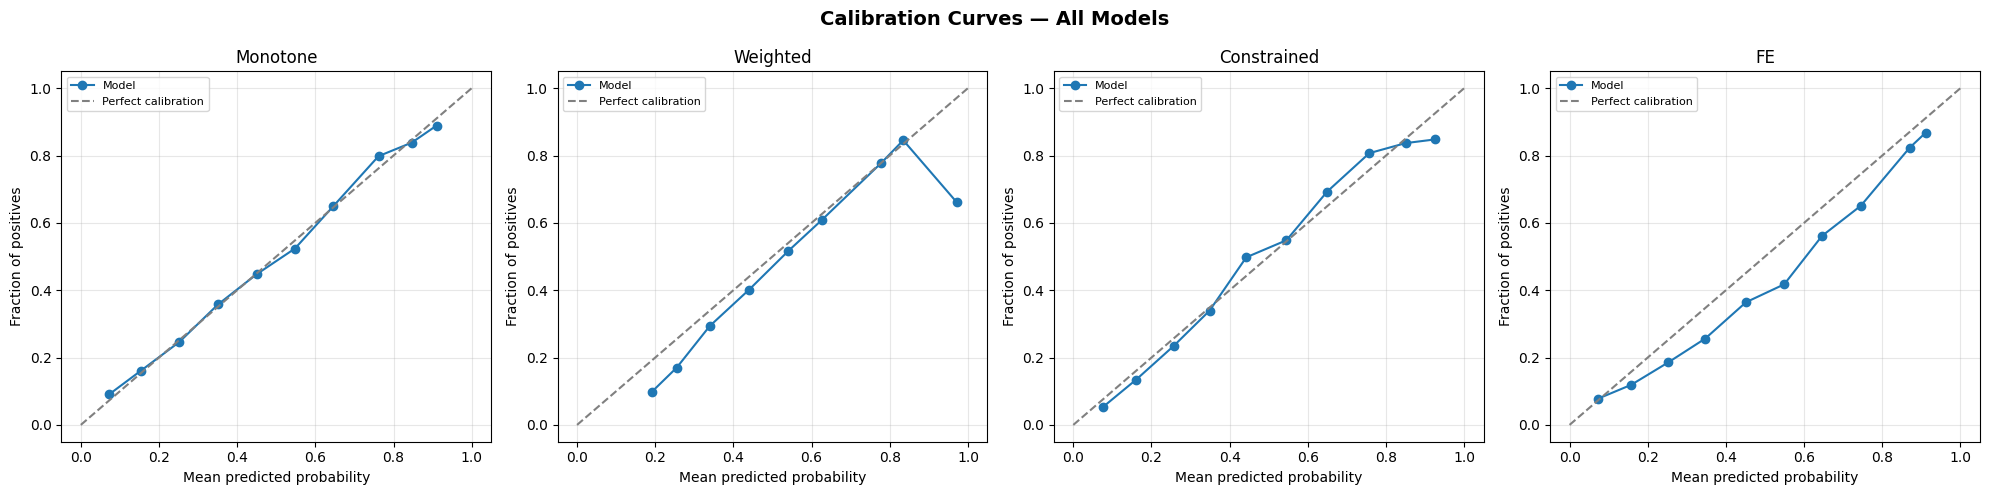

<Figure size 640x480 with 0 Axes>

In [37]:
# ## 4 · Calibration

fig, axes = plt.subplots(1, len(models_2), figsize=(5 * len(models_2), 5))
fig.suptitle("Calibration Curves — All Models", fontsize=14, fontweight="bold")

for ax, (model_name, (model, X)) in zip(axes, models_2.items()):
    y_prob = model.predict_proba(X)[:, 1]
    
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
    
    ax.plot(prob_pred, prob_true, marker="o", label="Model")
    ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfect calibration")
    ax.set_title(model_name)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig(OUTPUT_DIR/ "allmodel_c.png", dpi=150, bbox_inches="tight", facecolor="#0d0d1b")


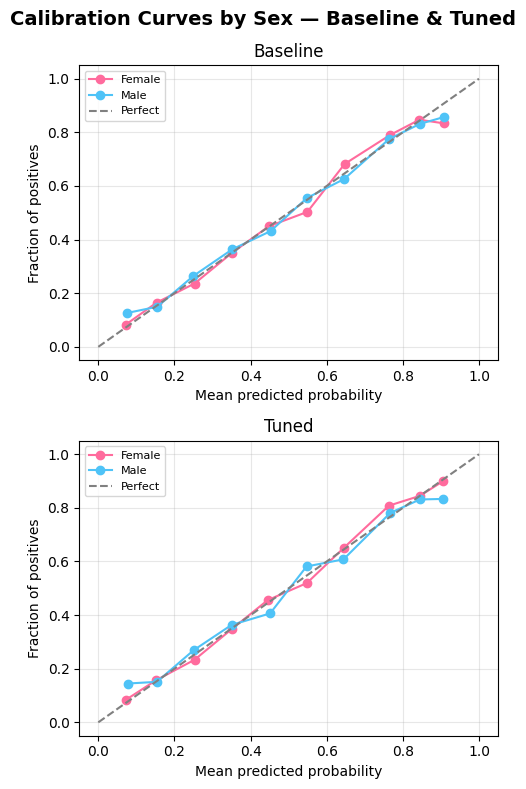


Model            F mean pred   F actual   F diff  M mean pred   M actual   M diff
--------------------------------------------------------------------------------
Baseline              0.4946     0.4933  +0.0013       0.4995     0.4994  +0.0001
Tuned                 0.4952     0.4933  +0.0019       0.4991     0.4994  -0.0004


In [42]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(5, 8))
fig.suptitle("Calibration Curves by Sex — Baseline & Tuned", fontsize=14, fontweight="bold")

for ax, model_name in zip(axes, ["Baseline", "Tuned"]):
    model, X = models[model_name]

    y_prob_f = model.predict_proba(X[female_mask])[:, 1]
    prob_true_f, prob_pred_f = calibration_curve(y_test[female_mask], y_prob_f, n_bins=10)

    y_prob_m = model.predict_proba(X[male_mask])[:, 1]
    prob_true_m, prob_pred_m = calibration_curve(y_test[male_mask], y_prob_m, n_bins=10)

    ax.plot(prob_pred_f, prob_true_f, marker="o", color="#ff6b9d", label="Female")
    ax.plot(prob_pred_m, prob_true_m, marker="o", color="#4fc3f7", label="Male")
    ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfect")
    ax.set_title(model_name)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "calibration_by_sex_baseline_tuned.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Calibration in the large by sex ──────────────────────
print(f"\n{'Model':<15} {'F mean pred':>12} {'F actual':>10} {'F diff':>8} {'M mean pred':>12} {'M actual':>10} {'M diff':>8}")
print("-" * 80)

for model_name in ["Baseline", "Tuned"]:
    model, X = models[model_name]
    prob_f   = model.predict_proba(X[female_mask])[:, 1]
    prob_m   = model.predict_proba(X[male_mask])[:, 1]
    actual_f = y_test[female_mask].mean()
    actual_m = y_test[male_mask].mean()
    diff_f   = prob_f.mean() - actual_f
    diff_m   = prob_m.mean() - actual_m
    print(f"{model_name:<15} {prob_f.mean():>12.4f} {actual_f:>10.4f} {diff_f:>+8.4f} {prob_m.mean():>12.4f} {actual_m:>10.4f} {diff_m:>+8.4f}")

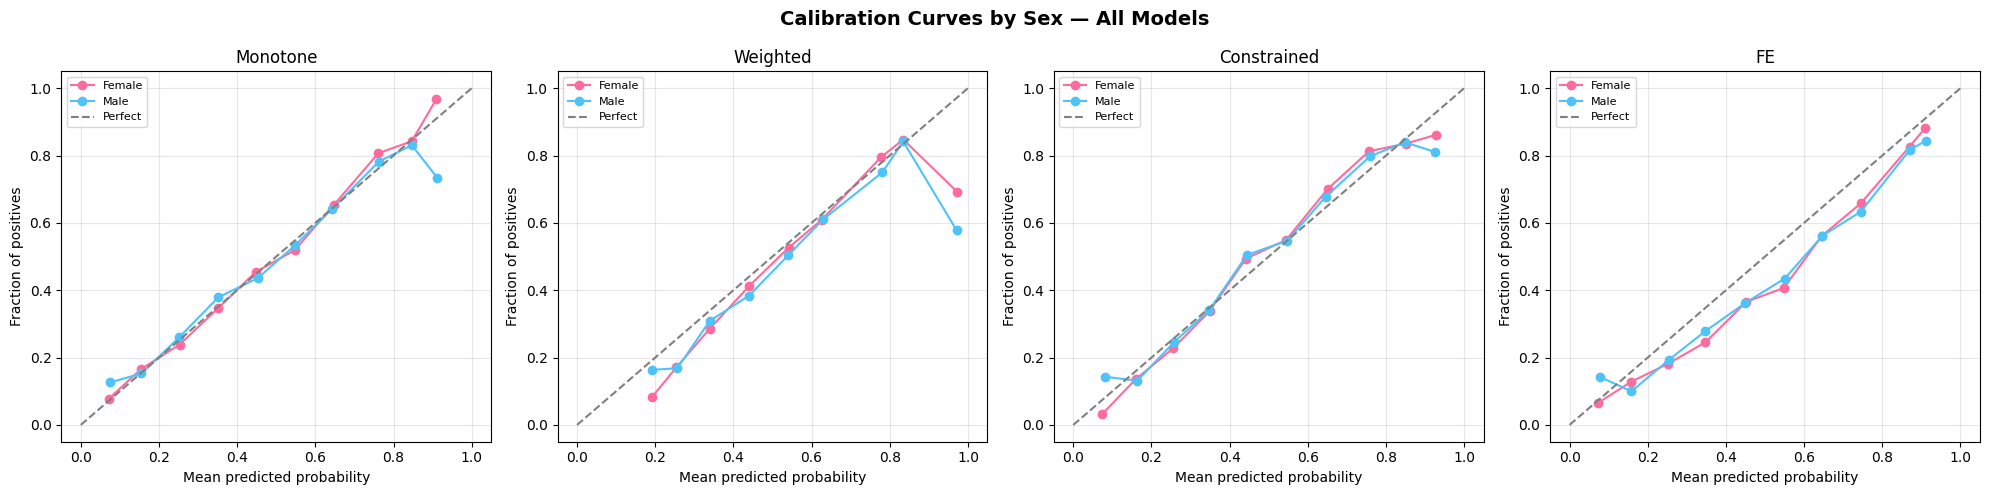


Model            F mean pred   F actual   F diff  M mean pred   M actual   M diff
--------------------------------------------------------------------------------
Baseline              0.4946     0.4933  +0.0013       0.4995     0.4994  +0.0001
Tuned                 0.4952     0.4933  +0.0019       0.4991     0.4994  -0.0004
Monotone              0.4949     0.4933  +0.0016       0.4998     0.4994  +0.0003
Weighted              0.5374     0.4933  +0.0441       0.5455     0.4994  +0.0460
Constrained           0.4954     0.4933  +0.0021       0.4983     0.4994  -0.0012
FE                    0.5669     0.4933  +0.0736       0.5737     0.4994  +0.0743


<Figure size 640x480 with 0 Axes>

In [44]:
# ## 4b · Sex-Stratified Calibration Curves

fig, axes = plt.subplots(1, len(models_2), figsize=(5 * len(models_2), 5))
fig.suptitle("Calibration Curves by Sex — All Models", fontsize=14, fontweight="bold")

for ax, (model_name, (model, X)) in zip(axes, models_2.items()):
    
    # Female
    y_prob_f = model.predict_proba(X[female_mask])[:, 1]
    prob_true_f, prob_pred_f = calibration_curve(y_test[female_mask], y_prob_f, n_bins=10)
    
    # Male
    y_prob_m = model.predict_proba(X[male_mask])[:, 1]
    prob_true_m, prob_pred_m = calibration_curve(y_test[male_mask], y_prob_m, n_bins=10)
    
    ax.plot(prob_pred_f, prob_true_f, marker="o", color="#ff6b9d", label="Female")
    ax.plot(prob_pred_m, prob_true_m, marker="o", color="#4fc3f7", label="Male")
    ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfect")
    
    ax.set_title(model_name)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig(OUTPUT_DIR / "calibration_by_sex.png", dpi=150, bbox_inches="tight")


# ── Calibration in the large by sex ──────────────────────
print(f"\n{'Model':<15} {'F mean pred':>12} {'F actual':>10} {'F diff':>8} {'M mean pred':>12} {'M actual':>10} {'M diff':>8}")
print("-" * 80)

for model_name, (model, X) in models.items():
    prob_f    = model.predict_proba(X[female_mask])[:, 1]
    prob_m    = model.predict_proba(X[male_mask])[:, 1]
    actual_f  = y_test[female_mask].mean()
    actual_m  = y_test[male_mask].mean()
    diff_f    = prob_f.mean() - actual_f
    diff_m    = prob_m.mean() - actual_m
    print(f"{model_name:<15} {prob_f.mean():>12.4f} {actual_f:>10.4f} {diff_f:>+8.4f} {prob_m.mean():>12.4f} {actual_m:>10.4f} {diff_m:>+8.4f}")

In [39]:
from sklearn.metrics import brier_score_loss

print(f"{'Model':<15} {'Overall':>10} {'Female':>10} {'Male':>10}  (lower = better, 0.25 = no skill)")
print("-" * 55)

for model_name, (model, X) in models.items():
    y_true = y_test_fe if model_name == "FE" else y_test

    bs_overall = brier_score_loss(y_true, model.predict_proba(X)[:, 1])
    bs_female  = brier_score_loss(y_true[female_mask], model.predict_proba(X[female_mask])[:, 1])
    bs_male    = brier_score_loss(y_true[male_mask],   model.predict_proba(X[male_mask])[:, 1])

    print(f"{model_name:<15} {bs_overall:>10.4f} {bs_female:>10.4f} {bs_male:>10.4f}")

Model              Overall     Female       Male  (lower = better, 0.25 = no skill)
-------------------------------------------------------
Baseline            0.1825     0.1793     0.1884
Tuned               0.1824     0.1790     0.1887
Monotone            0.1829     0.1795     0.1891
Weighted            0.1909     0.1875     0.1971
Constrained         0.1853     0.1818     0.1917
FE                  0.1885     0.1856     0.1940
